Made by: Miguel Jafert Serrano Mantilla

30/09/2022

Universidad Industrial De Santander

## Numerical methods for solving 1D partial differential equations

Here we're gonna solve partial diferential equations using spectral methods, these are in general really good methods but are even more usefull for elliptic equations with specific boundary conditions.


The general problem is:


$\mathcal{L}u(x) = S(x)\;\;\; : x \in U\subseteq R^d $ 

$\mathcal{B}u(y) = 0 \;\;\; : y \in \partial U$

Where $\mathcal{L}$ and $\mathcal{B}$ are linear differential operators, the PDE operator a a boundary condition operator, now we define a residue:


$R(x) = \mathcal{L}\bar{u}(x) - s(x) \neq 0$

Where: $\bar{u}(x)$ is the solution in a finite sub-space $P_N$ , of sobre Hilbert space of $L^2$. To have an accurate numerical solution the residue must be convergent.


Our solution $u(x)$ is gonna be approched using scoring functions:


$P_N \;\;: \;\; (\phi_0,...,\phi_N)\rightarrow \bar{u}(x) = \sum_{n=0}^N C_n\phi_n(x)$ 


And we need to test this scoring functions with another family of functions, the testing functions $(\xi_0,...,\xi_N)$

So, to ensure convergence, there is a relation that always must be met:

$\forall n \in \{0,...,N\} \,\; <\xi_n,R> = 0$

Knowing all of this we can know jump into the spectral numerical methods.

## Pseudo-spectral method

For this method, we're gonna use Dirac's delta distribution function as our testing functions, thus:

$\xi_n(x) = \delta(x - x_n)$

Where $x_n$ are the colocation dots of our grid, we must be carefull with this dots, because if we choose them arbitrarily can appear computational singularities, for example, if we use a equidistant grid and Chebhyshev polynomia as our scoring functions, a Gibb's effect is going to appear, that can be solved using Freyer series or choosing a correct quadrature for that many scoring functions already have got formulas to get the $x_n$. Now, lets check the convergence:

$<\xi_n , R> = 0 \rightarrow <\delta(x-x_n),R> = 0 \rightarrow R(x_n) = 0$

$\mathcal{L}\bar{u}(x_n) = s(x_n)$

And using our scoring functions:

$\sum_{k=0}^N \mathcal{L}\phi_k(x_n)C_k = s(x_n)$

This is a really good looking problem, because we all already know how to solve it, the problem's got the form:

$\hat{A}\vec{x} = \vec{b}$

So, our PDE problem becomes a matrix inversion problem, but the boundary conditions aren't implicit nor in the scoring function nor in the testing functions, so we must put into de matrix and the source vector our boundary conditions, lets make some examples:

## Helmholtz equation

First, lets give a general look to the equation a then solve a specific case, the Helmholtz equation has the form:

$\nabla^2u + \lambda^2u = f$

In this case $u$ is gonna be approached using Chebyshev's type 1 polynomia as follows:

$u(x) = \sum_{k=0}^N C_k T_k(x) \;\; x \in [-1,-1]$

With boundary conditions:

$u_R = g_1$

$u_L = g_2$

And to set the colocation dots, we're gonna use a Lovachevsky's quadrature, thus:

$x_n = cos\left(\frac{n\pi}{N}\right)\;\; n \in \mathbb{N}$

Having all of this we already can give a form to our problem and solve it:

$\sum_{k=0}^N\left[T''_k(x_n) + \lambda^2T_k(x_n)\right]C_k = f(x_n)$

For simplicity we're gonna define the therm of the summand as $T^{kn} = G_k(x_n)$

$ \begin{bmatrix}
T_0(x_l) & T_1(x_l) & T_2(x_l) & ... & T_N(x_l) \\
G_0(x_1) & G_1(x_1) & G_2(x_1) & ... & G_N(x_1) \\
... & ... & ... & ... & ... \\
G_0(x_{N-1}) & G_1(x_{N-1}) & G_2(x_{N-1}) & ... & G_N(x_{N-1}) \\
T_0(x_R) & T_1(x_R) & T_2(x_R) & ... & T_N(x_R) 
\end{bmatrix}  $
$\begin{bmatrix}
C_0 \\
C_1 \\
... \\
C_{N-1}\\
C_N
\end{bmatrix}$ $=$
$\begin{bmatrix}
g_2 \\
f(x_1) \\
... \\
f(x_{N-1})\\
g_1
\end{bmatrix}$ 

## Example 1: $\nabla^2u(x) -\lambda^2u(x) = x^2$
This is a Helmlhotz equation and it's got the following homogeneus Dirichlet boundary conditions:

$u(-1) = u(1) = 0$

Its exact solution for $\lambda = 4$ is the following:

$u(x) = \frac{-3}{(8e^{2} + e^{-2})}\left(e^{2x} + e^{-2x}\right) + \frac{1}{4}x^2 + \frac{1}{8}$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

def cheby(m,r):
    
    cheby_0 = 1.0
    cheby_1 = r
    
    if(m == 0):
        cheby = cheby_0
    elif m == 1:
        cheby = cheby_1
    elif m >= 2:
        for j in range(2, m+1):
            cheby_n = 2*r*cheby_1 - cheby_0
            cheby_0 = cheby_1
            cheby_1 = cheby_n
        cheby = cheby_n
    return cheby

def dcheby(m,r):
    
    dcheby_0 = 0
    dcheby_1 = 1
    
    if m == 0 :
        dcheby = dcheby_0
    elif m == 1:
        dcheby = dcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            dcheby_n = 2*cheby(j-1 , r) + 2*r*dcheby_1 - dcheby_0
            dcheby_0 = dcheby_1
            dcheby_1 = dcheby_n
        dcheby = dcheby_n
    return dcheby

def ddcheby(m,r):
    
    ddcheby_0 = 0
    ddcheby_1 = 0
    
    if m == 0:
        ddcheby = ddcheby_0
    elif m == 1:
        ddcheby = ddcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            ddcheby_n = 4*dcheby(j-1,r)+2*r*ddcheby_1 - ddcheby_0
            ddcheby_0 = ddcheby_1
            ddcheby_1 = ddcheby_n
        ddcheby = ddcheby_n
    return ddcheby

def exact(r):
    exact = (-3/(8*(np.exp(2) + np.exp(-2))))*(np.exp(2*r) + np.exp(-2*r)) +(1/4)*r**2 +(1/8) 
    return exact 

def f(r):
    return r**2

Time =  0.0023391246795654297  [s]


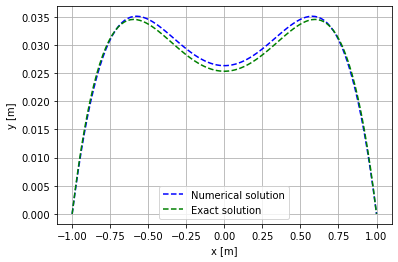

In [15]:
##============================================================##
#   This program solves the Helmholtzs equation:
#   u''(x) - lambda*u(x) = -f(x) u(-1)=u(1)=0 using the 
#   pseudo-spectral method and the chebychev polynomia
#   By: Miguel Jafert Serrano Mantilla
##============================================================##
#   Basic data:

#N = eval(input('Number of colocation points: '))
N = 4
#Nx = eval(input('Number of grid points: '))
Nx = 100
#lambd = eval(input('lambda = 4.0 default '))
lambd = 4.0

start = time.time()

##============================================================##
#   Arrays:

A = np.zeros((N+1 , N+1))    #Matrix to invert
b = np.zeros(N+1)            #Source vector
#aa = np.zeros(N+1)           #Solution vector
xx = np.linspace(-1,1,Nx)    #Grid vector
x = np.zeros(N + 1) 

##============================================================##
for i in range(0 , N+1):
    x[i] = np.cos(np.pi * i / N)

for i in range(0 , N+1):
    if (i == 0) or (i == N):
        b[i] = 0.0
    else :
        b[i] = f(x[i])
        
for i in range(0 , N+1):
    for l in range(0 , N+1):
        if (i==0) or (i == N):
            A[i , l] = cheby(l , x[i])
        else : 
            A[i , l] = -ddcheby(l , x[i]) + lambd*cheby(l , x[i])

##============================================================##
A_inv = np.linalg.inv(A)
aa = np.dot(A_inv , b)

y = np.zeros(Nx)
for i in range(0 , N + 1):
    y += aa[i]*cheby(i , xx)

end = time.time()
print('Time = ' , end - start , ' [s]')
##============================================================##
#Plotting
plt.plot(xx , y ,'--' , c = 'b' ,label = 'Numerical solution')
plt.plot(xx , exact(xx) , '--',c = 'g' , label = 'Exact solution')
plt.grid()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.show()

## Example 2: $u''(x) -4u'(x) +4u(x) = e^x -\frac{4e}{1+e^2}$

This equation also has homogeneus Dirichlet boundary conditions, thus: 

$u(-1)=u(1) = 0$

The exact solution is:

$u(x) = e^x - \frac{sinh(1)}{sinh(2)}e^{2x} -\frac{e}{1+e^2}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def cheby(m,r):
    
    cheby_0 = 1.0
    cheby_1 = r
    
    if(m == 0):
        cheby = cheby_0
    elif m == 1:
        cheby = cheby_1
    elif m >= 2:
        for j in range(2, m+1):
            cheby_n = 2*r*cheby_1 - cheby_0
            cheby_0 = cheby_1
            cheby_1 = cheby_n
        cheby = cheby_n
    return cheby

def dcheby(m,r):
    
    dcheby_0 = 0
    dcheby_1 = 1
    
    if m == 0 :
        dcheby = dcheby_0
    elif m == 1:
        dcheby = dcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            dcheby_n = 2*cheby(j-1 , r) + 2*r*dcheby_1 - dcheby_0
            dcheby_0 = dcheby_1
            dcheby_1 = dcheby_n
        dcheby = dcheby_n
    return dcheby

def ddcheby(m,r):
    
    ddcheby_0 = 0
    ddcheby_1 = 0
    
    if m == 0:
        ddcheby = ddcheby_0
    elif m == 1:
        ddcheby = ddcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            ddcheby_n = 4*dcheby(j-1,r)+2*r*ddcheby_1 - ddcheby_0
            ddcheby_0 = ddcheby_1
            ddcheby_1 = ddcheby_n
        ddcheby = ddcheby_n
    return ddcheby

def exact(r):
    c = (-4*np.exp(1))/(1 + np.exp(2))
    exact = np.exp(r) - (np.sinh(1) / np.sinh(2))*np.exp(2*r) + c/4 
    return exact 

def f(r):
    c = (-4*np.exp(1))/(1 + np.exp(2))
    return np.exp(r) + c

Time =  0.0031442642211914062  [s]


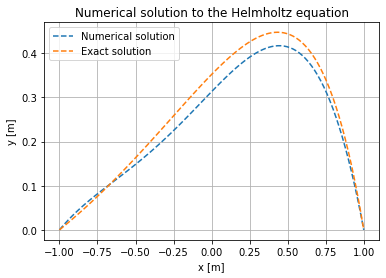

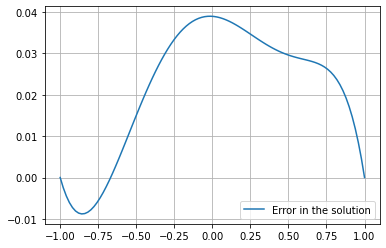

In [6]:
##============================================================##
#   This program solves the following equation:
#   y''(x) -4y'(x) + 4y(X) = f(x) y(-1)=y(1)=0 using the 
#   pseudo-spectral method and the chebycsev polynomia
##============================================================##
#   Basic data:

#N = eval(input('Number of colocation points: '))
#Nx = eval(input('Number of grid points: '))
N = 4
Nx = 100
start = time.time()

##============================================================##
#   Arrays:

A = np.zeros((N+1 , N+1))    #Matrix to invert
b = np.zeros(N+1)            #Source vector
#aa = np.zeros(N+1)           #Solution vector
xx = np.linspace(-1,1,Nx)    #Grid vector
x = np.zeros(N + 1) 

##============================================================##
for i in range(0 , N+1):
    x[i] = np.cos(np.pi * i / N)

for i in range(0 , N+1):
    if (i == 0) or (i == N):
        b[i] = 0.0
    else :
        b[i] = f(x[i])
        
for i in range(0 , N+1):
    for l in range(0 , N+1):
        if (i==0) or (i == N):
            A[i , l] = cheby(l , x[i])
        else : 
            A[i , l] = ddcheby(l,x[i])-4*dcheby(l,x[i])+4*cheby(l,x[i])

##============================================================##
A_inv = np.linalg.inv(A)
aa = np.dot(A_inv , b)

y = np.zeros(Nx)
for i in range(0 , N + 1):
    y += aa[i]*cheby(i , xx)

end = time.time()
print('Time = ' , end - start , ' [s]')
##============================================================##
#Plotting
plt.figure(1)
plt.plot(xx , y , '--' ,  label = 'Numerical solution')
plt.plot(xx , exact(xx) ,  '--' ,label = 'Exact solution')
plt.grid()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Numerical solution to the Helmholtz equation')
#plt.xlim(left = 0 , right = 1)
#plt.ylim(bottom = -5 , top = 5)
plt.legend()
plt.show()
##============================================================##
##Plotting the error
plt.figure(2)
plt.plot(xx, exact(xx)-y , label = 'Error in the solution')
plt.grid()
plt.legend()
plt.show()

## Galerkin's method

In this method, our scoring functions are the same testing functions, thus:

$\xi_n = \phi_n \;\; : \;\; n \in \{0,..,N\}$

Now, lets give a look to the littleness condition:

$<\phi_n,R> = 0 \iff <\phi_n, \mathcal{L}\bar{u} - s> = 0$

$\sum_{k=0}^N C_k\left[<\phi_n,\mathcal{L}\phi_k> - <\phi_n,s>\right] = 0$

Here also appears a matrix inversion problem, lets define the following matrix:

$L_{nk} = <\phi_n,\mathcal{L}\phi_k>$

$\sum_{k=0}^N L_{nk}C_k = <\phi_n,s> \;\; \equiv \;\; \hat{A}\vec{x} = \vec{b} $

$\mathcal{B}\phi_n(x) = 0 \;\;\; "Boundary\;\;condition\;\;operator"$

This method works even better thant the pseudo-spectral method, it's got a variational formulation such that:

$H_0^1(\Omega) = \{V \in H^1(\Omega) \;\; : \; v = 0 \;\; sobre \;\; \partial \Omega \}$

Now our PDE is going to describe a mapping as follows:

- 1) $U\;:\;[0,T] \rightarrow H_0^1(\Omega)$

- $t \rightarrow [u(t)]\;:\; \Omega \rightarrow \mathbb{R}$

- $x \rightarrow [u(t)](x) \;\;:= u(x,t)$

- 2) $f\;:\; [0,T] \rightarrow L^2(\Omega)$
- $t \rightarrow [f(t)]\;:\; \Omega \rightarrow \mathbb{R}$
- $x \rightarrow [f(t)](x) = f(x,t)$

Even that this seems like chineses it is only an elegant way to represent how a function works, first we're gonna from a time domain to a Hilbert's space in a surface $\Omega$ then, from that space we go to the real espace an then to our well known time-space domain.

## Diffusion equation: $\frac{\partial u}{\partial t}- \alpha^2 \frac{\partial^2u}{\partial x^2} = f(x,t) \;\; \subseteq [0,L]\times [0,T] $

This equation's got the following boundary and initial conditions:

- $u(0,t) = u(L,t) = 0 \;\; \forall L \in [0,T]$
- $u(x,0) = g(x) \;\; \forall x \int [0,L]$

let $v \in H_0^1(\Omega)$

$\int_0^L v \partial_t udx - \alpha^2\int_0^L v\partial_{xx}udx = \int_0^Lvfdx$

$\int_0^L v\partial_tudx + \alpha^2\int_0^L\partial_xv\partial_xudx = \int_0^Lvfdx$

$<[u(t)],v> + \alpha^2<u'(x),v'(x)> = <f(x),v>$

$<[u(t)],v> + \mathcal{P}<u(t),v(t)> = <f(x),v>$ 

The last equation is known as the weak Galerkin's formulation. Now, lets give a look to the initial conditions:

$\int_0^L u(x,0)vdx = \int_0^L g(x)vdx \;\; \equiv \;\; <[u(0)],v> = <v,g>$

Ñets give a base to $V_m$:

$\{\phi(x)\}^m_j \;\; : \;\; Gen\{\{\phi(x)\}^m_j \} = V_m \;\; :\;\; V_m \subseteq H_0^1(\Omega)$

Thus:

$\sum_{j=1}^m\left[\int_0^Lv\phi_j\dot{C_j(t)}dx + \int_0^L\alpha^2v'\phi'_jC_j(t)dx\right]= \int_0^Lvfdx$

Due to the fact our scoring functions are the same testing functions the PDE becomes:

$\sum_{i,j = 1}^m\left[\int_0^L\phi_i\phi_j dx\right]\dot{C_j(t)} + \alpha^2\sum_{i,j=1}^m\left[\int_0^L\phi_i'\phi_j'dx\right]C_j(t) = \sum_{i=1}^m\int_0^L\phi_ifdx$

This last equation get translate as:

$\hat{M}\vec{\dot{G}}(t) + \hat{A}\vec{C}(t) = \vec{b}(t) $

where:

$M_{ij} = \int_0^L \phi_i\phi_jdx \;\; A_{ij} = \alpha^2\int_0^L\phi'_i\phi'_jdx \;\; b_i = \int_0^Lf\phi_idx$

## Example 2 (With Galerkin) : $u''(x) -4u'(x) +4u(x) = e^x -\frac{4e}{1+e^2}$

This equation also has homogeneus Dirichlet boundary conditions, thus: 

$u(-1)=u(1) = 0$

The exact solution is:

$u(x) = e^x - \frac{sinh(1)}{sinh(2)}e^{2x} -\frac{e}{1+e^2}$

Here we must be really carefull, because we can't use the Chebyshev's polynomials because they don't anhilate on the boundary, because of that we're gonna define new polynomials from the Chebyshev's polynomials used before, thus:

- If the Chebyshev's order is even: $\phi(x) = T_{2k}(x) - T_0(x)$
- If the Chebyshev's order is odd: $\phi(x) = T_{2k-1}(x) - T_1(x)$

And because our problem doesn't deppend on time the problem becomes:

$\sum_{i,j=1}^m\left[\int_{-1}^1 (\phi''_j\phi_i - 4\phi'_j\phi_i + 4\phi_i\phi_j)dx\right] = \int_{-1}^1\phi_ifdx$

Thus:

$M_{ij} = \int_{-1}^1 (\phi''_j\phi_i - 4\phi'_j\phi_i + 4\phi_i\phi_j)dx \;\;\; b_i = \int_{-1}^1\phi_ifdx$

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.integrate import quad

def cheby(r,m):
    
    cheby_0 = 1.0
    cheby_1 = r
    
    if(m == 0):
        cheby = cheby_0
    elif m == 1:
        cheby = cheby_1
    elif m >= 2:
        for j in range(2, m+1):
            cheby_n = 2*r*cheby_1 - cheby_0
            cheby_0 = cheby_1
            cheby_1 = cheby_n
        cheby = cheby_n
    return cheby

def dcheby(r,m):
    
    dcheby_0 = 0
    dcheby_1 = 1
    
    if m == 0 :
        dcheby = dcheby_0
    elif m == 1:
        dcheby = dcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            dcheby_n = 2*cheby(r , j -1) + 2*r*dcheby_1 - dcheby_0
            dcheby_0 = dcheby_1
            dcheby_1 = dcheby_n
        dcheby = dcheby_n
    return dcheby

def ddcheby(r,m):
    
    ddcheby_0 = 0
    ddcheby_1 = 0
    
    if m == 0:
        ddcheby = ddcheby_0
    elif m == 1:
        ddcheby = ddcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            ddcheby_n = 4*dcheby(r , j-1)+2*r*ddcheby_1 - ddcheby_0
            ddcheby_0 = ddcheby_1
            ddcheby_1 = ddcheby_n
        ddcheby = ddcheby_n
    return ddcheby

def phi(r,m):
    if m%2 == 0 :
        phi = cheby(r,m+2) - cheby(r,0)
    else:
        phi = cheby(r,m+2) - cheby(r,1)
    return phi

def dphi(r,m):
    if m%2 == 0:
        dphi = dcheby(r,m+2) - dcheby(r,0)
    else :
        dphi = dcheby(r,m+2) - dcheby(r,1)
    return dphi

def ddphi(r,m):
    if m%2 == 0:
        ddphi = ddcheby(r,m+2) - ddcheby(r,0)
    else :
        ddphi = ddcheby(r,m+2) - ddcheby(r,1)
    return ddphi

def exact(r):
    c = (-4*np.exp(1))/(1 + np.exp(2))
    exact = np.exp(r) - (np.sinh(1) / np.sinh(2))*np.exp(2*r) + c/4 
    return exact 

def f(r):
    c = (-4*np.exp(1))/(1 + np.exp(2))
    return np.exp(r) + c

def fun(r,m,p):
    fun = 4*phi(r,p)*phi(r,m)-4*dphi(r,p)*phi(r,m)+ddphi(r,p)*phi(r,m)
    return fun

def fub(r,m):
    return f(r) * phi(r,m)

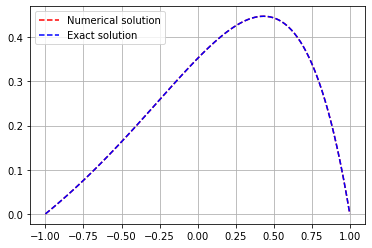

In [13]:
#N = eval(input('Write the number of polynomials: '))
#Nx = eval(input('Write the number of points of the grid: '))
N = 6
Nx = 100

x = np.linspace(-1,1,Nx)
A = np.zeros((N,N))
m_array = np.arange(0,N,1)
p_array = np.arange(0,N,1)
    
sour_int = np.array([[m , quad(fub , -1 , 1 , args=(m))[0]] for m in m_array])
b = sour_int.T[1]

mat_int = np.array([[m,p , quad(fun ,-1,1,args=(m,p))[0]] for m in m_array for p in p_array])
aux = mat_int.T[2]

k = 0
for m in range(0,N):
    for p in range(0,N):
        A[m,p] = aux[k]
        k += 1

sol = np.dot(np.linalg.inv(A) , b)
y = np.zeros(Nx)
y_exc = exact(x)
for i in range(0,N):
    y += sol[i]*phi(x,i)
    
plt.plot(x,y , '--' , color = 'r' , label = 'Numerical solution')
plt.plot(x,y_exc , '--' ,  color = 'b' , label = 'Exact solution')
plt.grid()
plt.legend()
plt.show()

## Tau method

In this case neither scoring or testing functions are the same, and the scoring functions don't fulfil the boundary conditions, this means:

$\mathcal{B}\phi_n(x) \neq 0$

Thus we must find a new basis such that:

$\mathcal{B}\phi_n(x) = \sum_{p=0}^M b_{pn}g_p(x)$

Thus:

$\mathcal{B}\bar{u}(x) = \rightarrow \sum_{k=0}^{N}\sum_{p=0}^M C_kb_{pk}g_p(x) = 0 $

$\sum_{k=0}^Nb_{pk}C_k = 0$

So, the Tau method reduces to this two equations:

$\sum_{k=0}^NL_{nk}C_k = <\phi_n,s> \;\;\; 0\leq n \leq N-(M+1)$

$\sum_{k=0}^N b_{pk}C_k = 0 \;\;\; 0\leq p \leq M$